# Introduction

Howdy! I hope that doing great! My name is Vugar, I am studying Petroleum Engineering at Baku Higher Oil School. This notebook can be considered some part of my Holberton School AZ journey. Enjoy and do not hesitate to feedback at the end!

Below you can open this notebook at colab.google!

<a target="_blank" href="https://colab.research.google.com/github/vugaer/OpenData.AZ-Analysis/blob/master/analyze.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Initialization

Checking the version of Python installed. The next steps will be to:

*   import libraries
*   determine functions/classes (if needed)
*   create list of URLs.

So let's begin!

In [2]:
!python --version
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import csv

Python 3.9.25


We will save our datasets in the folder `./datasets`.

In [3]:
!rm -rf ./datasets
!mkdir ./datasets

Let's create a **list** where we will insert direct URLs for downloading csv files from `opendata.az`

In [4]:
### URLs can be inserted directly for the installation ###

### ToC

# 0 # NO DATA ON THE 0-th INDEX!
# 1 # Nəqliyyat sektorunda sərnişin daşınmasından əldə olunan gəlir ('https://opendata.az/@dsk/revenue-from-passenger-transportation-in-the-transportation-sector')
# 2 # Nəqliyyat sektorunda əlaqə növləri üzrə sərnişin daşınması, min sərnişin. ('https://opendata.az/@dsk/neqliyyat-sektorunda-elaqe-novleri-uzre-sernisin-dasinmasi-statistikasi')
# 3 # Nəqliyyat üzrə əsas makro göstəricilər ('https://opendata.az/@dsk/key-macro-indicators-for-transport')
# 4 # Nəqliyyat sektorunda 1 sərnişinin orta daşınma məsafəsi ('https://opendata.az/@dsk/average-transportation-distance-of-1-passenger-in-the-transport-sector/r/c488a8eb-bfe2-42ea-8a31-894e38492345')
# 5 # [not used] Boru kəməri nəqliyyatı üzrə əsas göstəricilər (natura ifadəsində) ('https://opendata.az/@dsk/boru-kemeri-neqliyyati-ile-bagli-statistik-gostericiler/r/d687598e-1c24-4621-8818-e5dd4a059412')

opendataurls = [None, 'https://admin.opendata.az/dataset/1cb0a662-8737-45c2-a3f8-c8fa21888a1a/resource/d51060b9-27cf-4dab-b2b2-4397b33371af/download/nqliyyat-sektorunda-srniin-danmasndan-ld-olunan-glir-min-manat-dt_bj_029.csv',
                'https://admin.opendata.az/dataset/467cbf09-b828-47f7-acb1-befdba793435/resource/059d5f88-9b3b-42f5-ab08-b2b4525ed687/download/nqliyyat-sektorunda-laq-novlri-uzr-srniin-danmas-min-srniin-dt_bj_021.csv',
                'https://admin.opendata.az/dataset/2bf54269-fa55-4b9a-859b-2bd06c74f3d6/resource/1fe4226b-f616-4c95-8aa7-f7f62b9eb404/download/nqliyyat-uzr-sas-makro-gostricilr-dt_bj_002.csv',
                'https://admin.opendata.az/dataset/f3d36c3a-8bdc-4ceb-9bd5-2c73d2db2d8d/resource/c488a8eb-bfe2-42ea-8a31-894e38492345/download/nqliyyat-sektorunda-1-srniinin-orta-danma-msafsi-dt_bj_050.csv',
                'https://admin.opendata.az/dataset/4b62b286-efa5-455f-8b04-dadbf5ae2c23/resource/d687598e-1c24-4621-8818-e5dd4a059412/download/boru-kmri-nqliyyat-uzr-sas-gostricilr-natura-ifadsind-dt_bj_051.csv',
                ]

Creating 3 functions as:

1.   **downloadf** -> Download spesific dataset from the list `opendataurls` by their defined index.
2.   **loadf** -> it will be used to read csv files, converting them into pandas format. We will use `csv.sniffer` to determine delimiter.
3.   **sniffer** -> that will be used by `loadf` function

In [5]:
def loadf(index, bytes_to_sniff=4096, encoding='utf-8'):
  path = f'./datasets/data{index}.csv'
  return pd.read_csv(path, sep=sniffer(path, bytes_to_sniff, encoding))

def sniffer(file_path, bytes_to_sniff=4096, encoding='utf-8'):
    with open(file_path, 'r', newline='', encoding=encoding) as file:
        return csv.Sniffer().sniff(file.read(bytes_to_sniff)).delimiter

def downloadf(index):
    !wget -q --show-progress "{opendataurls[index]}" -O "./datasets/data{index}.csv"

Use the below to automatically download and load all the datasets defined in `opendataurls`

```python
for index in range(1, len(opendataurls)):
  downloadf(index)
  globals()[f'df{index}'] = loadf(index)
```

# DataFrames

## `df1` preprocessing

This data preprocessed on:
*   `Year` replaced as index
*   `Columns translated to English
*    Unnecessary columns dropped
*    `Year` converted to `DateTime` format.
*    `Year` sorted

In [6]:
# In just a few words, we will download, determine seperator, and load csv into dataframe!
# Nəqliyyat sektorunda sərnişin daşınmasından əldə olunan gəlir

downloadf(1)
df1 = loadf(1)
df1.head()

./datasets/data1.cs 100%[===================>]   2.59K  --.-KB/s    in 0s      


,Year,Unnamed: 1,Cəmi (min manat),Dəmir yolu (min manat),Dəniz (min manat),Hava (min manat),Avtomobil (min manat),Avtobus (min manat),Taksi (min manat),Metro (min manat),Tramvay (min manat),Trolleybus (min manat)
0,2024,NaN,3425222.0,11696.0,1085.0,2099001.0,1213002.0,959319.0,253683.0,100438.0,0.0,0.0
1,2023,NaN,2672397.0,9274.0,3923.0,1473613.0,1102104.0,870662.0,231442.0,83483.0,0.0,0.0
2,2022,NaN,2239187.0,4827.0,6179.0,1261872.0,905559.0,681886.0,223673.0,60750.0,0.0,0.0
3,2021,NaN,1298349.0,1837.0,2996.0,635110.0,632252.0,474553.0,157699.0,26154.0,0.0,0.0
4,2020,NaN,912765.0,4248.0,1128.0,343383.0,542383.0,408815.0,133568.0,21623.0,0.0,0.0


In [7]:
df1 = loadf(1)  # reload doesn't affect

df1.set_index(df1['Year'], inplace=True)
df1.drop(columns=['Year', 'Unnamed: 1', 'Tramvay (min manat)', 'Trolleybus (min manat)'], inplace=True)
en2azcols = {
    "Cəmi (min manat)": "Total Revenue (per thousand manats)",
    "Dəmir yolu (min manat)": "Railway",
    "Dəniz (min manat)": "Sea",
    "Hava (min manat)": "Air",
    "Avtomobil (min manat)": "Automobile",
    "Avtobus (min manat)": "Bus",
    "Taksi (min manat)": "Taxi",
    "Metro (min manat)": "Metro"
}
df1.rename(columns=en2azcols, inplace=True)
df1.index = pd.to_datetime(df1.index, format='%Y')
df1.sort_index(ascending=True, inplace=True)

df1.head()

,Total Revenue (per thousand manats),Railway,Sea,Air,Automobile,Bus,Taxi,Metro
Year,,,,,,,,
1995-01-01,74114.0,1053.0,2809.0,48605.0,19063.0,17065.0,1998.0,2120.0
1996-01-01,84765.0,1140.0,1150.0,57119.0,21830.0,17034.0,4796.0,3058.0
1997-01-01,114437.0,1602.0,1074.0,45501.0,61229.0,48965.0,12264.0,4437.0
1998-01-01,133338.0,4188.0,446.0,40639.0,82827.0,62869.0,19958.0,4666.0
1999-01-01,127668.0,3013.0,381.0,31094.0,88429.0,64567.0,23862.0,4475.0


### <font color="#36BCF7FF">Insights from the data</font>

From the data, it is obvious how revenue (and probably usage) decreased after COVID-19 virus got spread.

In terms of automobile, we can or might reason the partnership with the China in terms of hybrid/electric cars, taxes on customs, increase in the fuel prices and et cetera.

Regarding a little bit increase in the taxi, it may be possible that it is due to the increasing popularity of Bolt, Uber and other apps during those times which regulated the taxi system, making and circulating the money in the system.

It is very unfortunate to see little revenue from metro during these years (this one is not my subjective opinion rather what the data shows)

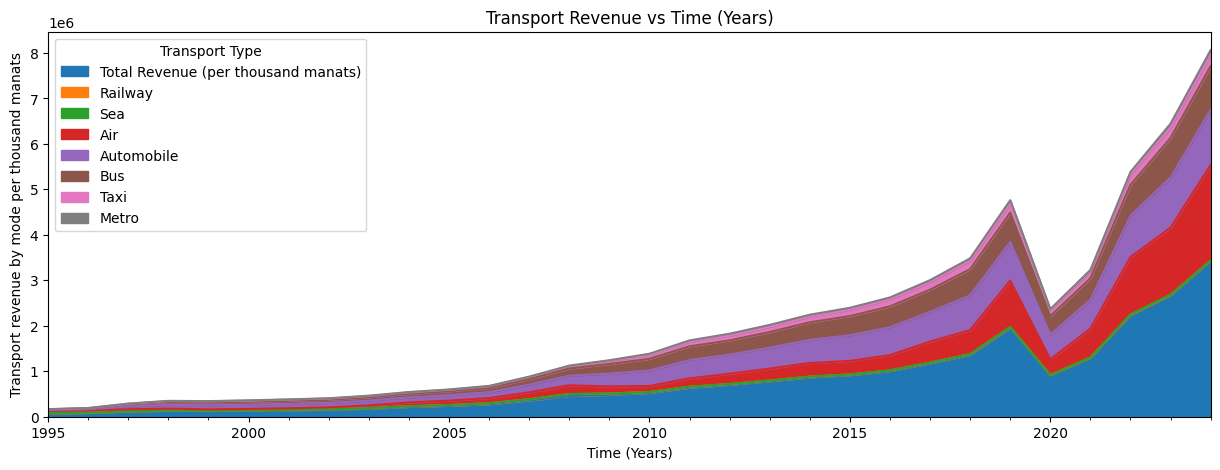

In [8]:
df1.plot(
    kind='area',
    figsize=(15, 5),
    title='Transport Revenue vs Time (Years)'
)

plt.ylabel('Transport revenue by mode per thousand manats')
plt.xlabel('Time (Years)')
plt.legend(title='Transport Type', loc='best')
plt.show()

## `df2` preprocessing

This data preprocessed on:
*   `Year` replaced as index
*   `Columns translated to English
*    Unnecessary columns dropped
*    `Year` converted to `DateTime` format.
*    `Year` sorted

In [9]:
# In just a few words, we will download, determine seperator, and load csv into dataframe!
# Nəqliyyat sektorunda əlaqə növləri üzrə sərnişin daşınması, min sərnişin.

downloadf(2)
df2 = loadf(2)
df2.head()

./datasets/data2.cs 100%[===================>]   3.77K  --.-KB/s    in 0s      


,Year,Unnamed: 1,Bütün əlaqə növləri üzrə-cəmi (min sərnişin),Şəhərlərarası (min sərnişin),avtobus (min sərnişin),dəmir yolu (min sərnişin),dəniz (min sərnişin),hava (min sərnişin),Şəhərətrafı (min sərnişin),avtobus (min sərnişin).1,dəmir yolu (min sərnişin).1,Şəhərdaxili (min sərnişin),avtobus (min sərnişin).2,minik taksiləri (min sərnişin),metro (min sərnişin),Tramvay (min sərnişin),Trolleybus (min sərnişin)
0,2022,NaN,1621129.0,34091.0,31731.0,85.0,21.0,2254.0,302092.0,297040.0,5052.0,1284946.0,992436.0,83814.0,208696.0,0.0,0.0
1,2021,NaN,1214153.0,27061.0,25831.0,79.0,18.0,1133.0,214499.0,211752.0,2747.0,972593.0,795417.0,86944.0,90232.0,0.0,0.0
2,2020,NaN,1177632.0,30769.0,29864.0,307.0,20.0,578.0,238197.0,236380.0,1817.0,908666.0,789024.0,44933.0,74709.0,0.0,0.0
3,2019,NaN,2056516.0,56409.0,52472.0,1211.0,22.0,2704.0,421169.0,418530.0,2639.0,1578938.0,1270363.0,71893.0,236682.0,0.0,0.0
4,2018,NaN,2002836.0,54620.0,51142.0,1063.0,16.0,2399.0,409702.0,407924.0,1778.0,1538514.0,1238170.0,69328.0,231016.0,0.0,0.0


In [10]:
df2 = loadf(2)  # reload doesn't affect

df2.set_index(df2['Year'], inplace=True)
df2.drop(columns=['Year', 'Unnamed: 1', 'Tramvay (min sərnişin)', 'Trolleybus (min sərnişin)'], inplace=True)

en2azcols = {
    "Bütün əlaqə növləri üzrə-cəmi (min sərnişin)": "Total (thousand passengers)",
    "Şəhərlərarası (min sərnişin)": "Between Cities (thousand passengers)",
    "avtobus (min sərnişin)": "Bus – Intercity (thousand passengers)",
    "dəmir yolu (min sərnişin)": "Railway – Intercity (thousand passengers)",
    "dəniz (min sərnişin)": "Sea – Intercity (thousand passengers)",
    "hava (min sərnişin)": "Air – Intercity (thousand passengers)",

    "Şəhərətrafı (min sərnişin)": "Suburban (thousand passengers)",
    "avtobus (min sərnişin).1": "Bus – Suburban (thousand passengers)",
    "dəmir yolu (min sərnişin).1": "Railway – Suburban (thousand passengers)",

    "Şəhərdaxili (min sərnişin)": "Urban (thousand passengers)",
    "avtobus (min sərnişin).2": "Bus – Urban (thousand passengers)",
    "minik taksiləri (min sərnişin)": "Taxi – Urban (thousand passengers)",
    "metro (min sərnişin)": "Metro – Urban (thousand passengers)"
}

df2.rename(columns=en2azcols, inplace=True)
df2.index = pd.to_datetime(df2.index, format='%Y')
df2.sort_index(ascending=True, inplace=True)

df2.head()

,Total (thousand passengers),Between Cities (thousand passengers),Bus – Intercity (thousand passengers),Railway – Intercity (thousand passengers),Sea – Intercity (thousand passengers),Air – Intercity (thousand passengers),Suburban (thousand passengers),Bus – Suburban (thousand passengers),Railway – Suburban (thousand passengers),Urban (thousand passengers),Bus – Urban (thousand passengers),Taxi – Urban (thousand passengers),Metro – Urban (thousand passengers)
Year,,,,,,,,,,,,,
1995-01-01,671911.0,10659.0,6908.0,2560.0,60.0,1131.0,145577.0,139182.0,6395.0,515675.0,330075.0,9844.0,150000.0
1996-01-01,721349.0,8009.0,5220.0,1499.0,39.0,1251.0,139729.0,136648.0,3081.0,573611.0,370601.0,10468.0,171598.0
1997-01-01,780810.0,11833.0,9286.0,1382.0,43.0,1122.0,191618.0,189211.0,2407.0,577359.0,382596.0,19323.0,159527.0
1998-01-01,850070.0,13564.0,11429.0,1282.0,20.0,833.0,193271.0,190266.0,3005.0,643235.0,467290.0,19782.0,143823.0
1999-01-01,854099.0,20441.0,18833.0,897.0,14.0,697.0,185801.0,182649.0,3152.0,647857.0,499568.0,21458.0,119249.0


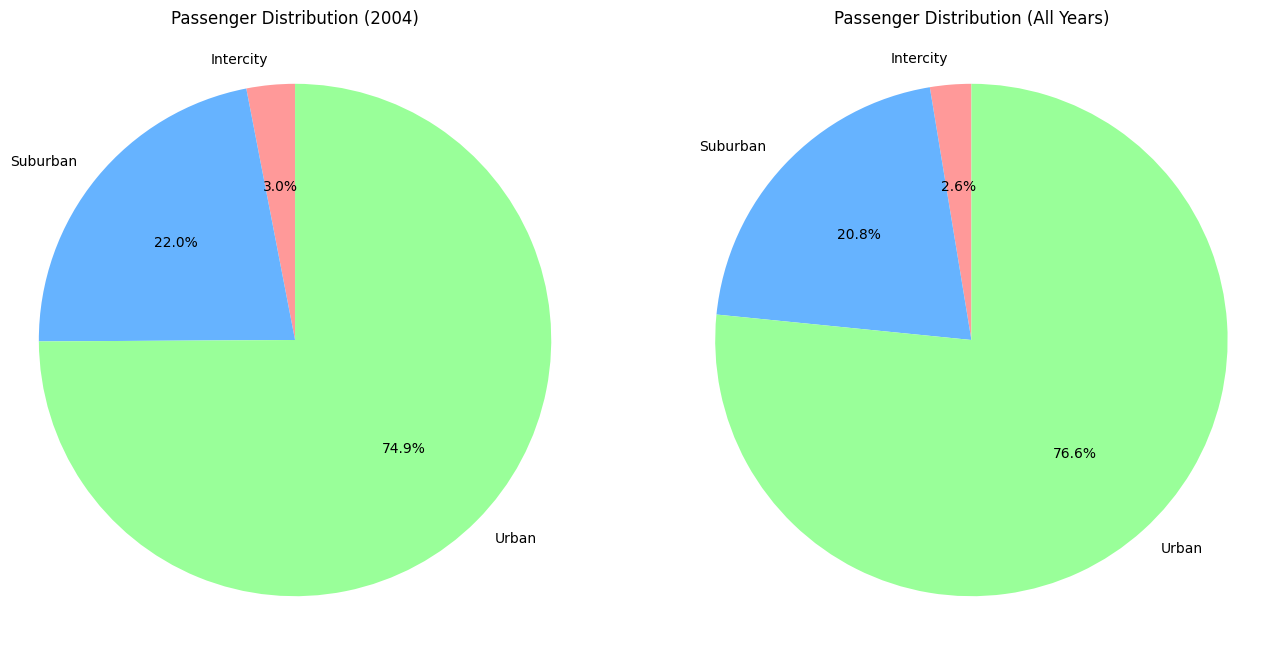

In [11]:
year = 2004

row = df2.loc[str(year)].iloc[-1]
year_sizes = [
    row['Between Cities (thousand passengers)'],
    row['Suburban (thousand passengers)'],
    row['Urban (thousand passengers)']
]
total_sizes = [
    df2['Between Cities (thousand passengers)'].sum(),
    df2['Suburban (thousand passengers)'].sum(),
    df2['Urban (thousand passengers)'].sum()
]
labels = ['Intercity', 'Suburban', 'Urban']
colors = ['#ff9999', '#66b3ff', '#99ff99']
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
# selected year
axes[0].pie(
    year_sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
axes[0].set_title(f'Passenger Distribution ({year})')
axes[0].axis('equal')
# all years total
axes[1].pie(
    total_sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
axes[1].set_title('Passenger Distribution (All Years)')
axes[1].axis('equal')
plt.show()

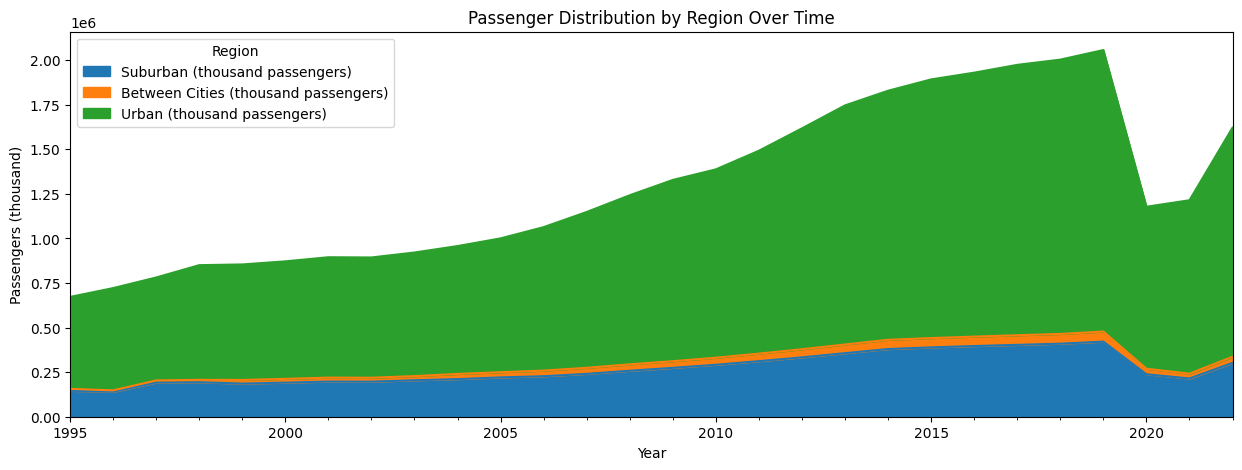

In [12]:
df2_filtered = df2[['Suburban (thousand passengers)', 'Between Cities (thousand passengers)','Urban (thousand passengers)']]

df2_filtered.plot(
    kind='area',
    figsize=(15, 5),
    title='Passenger Distribution by Region Over Time'
)

plt.ylabel('Passengers (thousand)')
plt.xlabel('Year')
plt.legend(title='Region', loc='best')
plt.show()

## `df3` preprocessing

This data preprocessed on:
*   `Year` replaced as index
*   `Columns translated to English
*    Unnecessary columns dropped
*    Units standartized as 1e3 (thousand)
*    `Year` converted to `DateTime` format.
*    `Year` sorted

In [13]:
# In just a few words, we will download, determine seperator, and load csv into dataframe!
# Nəqliyyat üzrə əsas makro göstəricilər

downloadf(3)
df3 = loadf(3)
df3.head()

./datasets/data3.cs 100%[===================>]   1.51K  --.-KB/s    in 0s      


,Year,Unnamed: 1,Əlavə dəyər (cari qiymətlərlə) (mln.manat),Ümumi mənfəət (cari qiymətlərlə) (mln.manat),Xalis mənfəət (cari qiymətlərlə) (mln.manat),Orta aylıq nominal əmək haqqı (manat),Əsas fondlar (ilin sonuna) (mln.manat),Əsas kapitala investisiyalar (mln.manat)
0,2024,NaN,8823.0,6895.0,5264.0,1395.0,22229.0,5863.0
1,2023,NaN,7827.0,6134.0,4528.0,1279.0,21245.0,5417.0
2,2022,NaN,8122.0,6520.0,5136.0,1124.0,18942.0,4613.0
3,2021,NaN,6390.0,4891.0,4054.0,953.0,17261.0,2857.0
4,2020,NaN,5175.0,3814.0,2534.0,886.0,15705.0,2092.0


In [14]:
df3 = loadf(3)  # reload doesn't affect

df3.set_index(df3['Year'], inplace=True)
df3.drop(columns=['Year', 'Unnamed: 1'], inplace=True)

mln_cols = ["Əlavə dəyər (cari qiymətlərlə) (mln.manat)", "Ümumi mənfəət (cari qiymətlərlə) (mln.manat)", "Xalis mənfəət (cari qiymətlərlə) (mln.manat)", "Əsas fondlar (ilin sonuna) (mln.manat)", "Əsas kapitala investisiyalar (mln.manat)"]

df3[mln_cols] *= 1000
df3['Orta aylıq nominal əmək haqqı (manat)'] /= 1000

en2azcols3 = {
    "Əlavə dəyər (cari qiymətlərlə) (mln.manat)": "Value added (current prices) (thousand manats)",
    "Ümumi mənfəət (cari qiymətlərlə) (mln.manat)": "Gross profit (current prices) (thousand manats)",
    "Xalis mənfəət (cari qiymətlərlə) (mln.manat)": "Net profit (current prices) (thousand manats)",
    "Orta aylıq nominal əmək haqqı (manat)": "Average monthly nominal wage (thousand manats)",
    "Əsas fondlar (ilin sonuna) (mln.manat)": "Fixed assets (end of year) (thousand manats)",
    "Əsas kapitala investisiyalar (mln.manat)": "Investments in fixed capital (thousand manats)"
}

df3.rename(columns=en2azcols3, inplace=True)
df3.index = pd.to_datetime(df3.index, format='%Y')
df3.sort_index(ascending=True, inplace=True)

df3.head()

,Value added (current prices) (thousand manats),Gross profit (current prices) (thousand manats),Net profit (current prices) (thousand manats),Average monthly nominal wage (thousand manats),Fixed assets (end of year) (thousand manats),Investments in fixed capital (thousand manats)
Year,,,,,,
1998-01-01,324000.0,245000.0,131000.0,0.058,1853000.0,53000.0
1999-01-01,315000.0,201000.0,105000.0,0.048,1925000.0,84000.0
2000-01-01,453000.0,327000.0,229000.0,0.052,2064000.0,44000.0
2001-01-01,436000.0,309000.0,224000.0,0.060,2156000.0,59000.0
2002-01-01,474000.0,334000.0,250000.0,0.066,2102000.0,89000.0


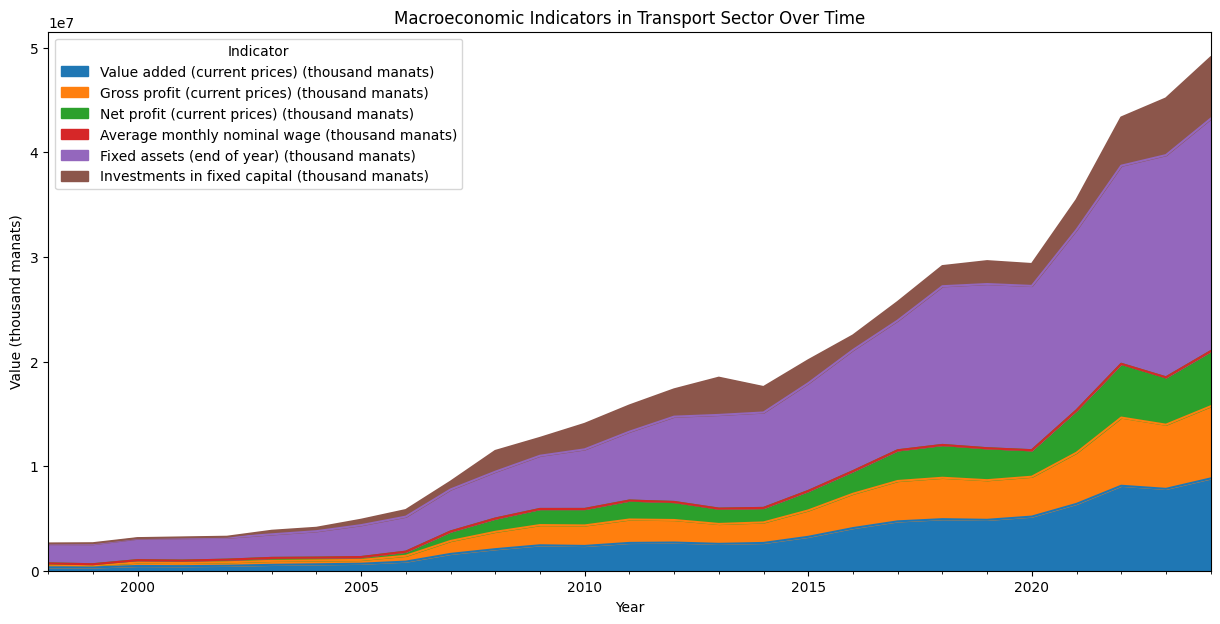

In [15]:
selected_columns = [
    "Value added (current prices) (thousand manats)",
    "Gross profit (current prices) (thousand manats)",
    "Net profit (current prices) (thousand manats)",
    "Average monthly nominal wage (thousand manats)",
    "Fixed assets (end of year) (thousand manats)",
    "Investments in fixed capital (thousand manats)"
]

df3[selected_columns].plot(
    kind='area',
    figsize=(15, 7),
    title='Macroeconomic Indicators in Transport Sector Over Time'
)

plt.ylabel('Value (thousand manats)')
plt.xlabel('Year')
plt.legend(title='Indicator', loc='best')
plt.show()

## `df4` preprocessing

This data preprocessed on:
*   `Year` replaced as index
*   `Columns translated to English
*    Unnecessary columns dropped
*    `Year` converted to `DateTime` format.
*    `Year` sorted

In [16]:
# In just a few words, we will download, determine seperator, and load csv into dataframe!
# Nəqliyyat sektorunda 1 sərnişinin orta daşınma məsafəsi.

downloadf(4)
df4 = loadf(4)
df4.head()

./datasets/data4.cs 100%[===================>]   1.62K  --.-KB/s    in 0s      


,Year,Unnamed: 1,Cəmi (kilometr),Dəmir yolu (kilometr),Dəniz (kilometr),Hava (kilometr),Metro (kilometr),Avtomobil (kilometr),Avtobus (kilometr),Taksi (kilometr)
0,2024,NaN,18.9,44.2,457.7,1950.3,11.8,15.4,15.2,18.7
1,2023,NaN,17.6,43.7,468.4,1813.2,11.8,15.1,14.9,18.5
2,2022,NaN,17.6,37.8,476.6,2128.2,11.8,15.0,14.8,18.6
3,2021,NaN,16.7,36.8,474.6,2060.0,11.0,15.1,14.7,19.2
4,2020,NaN,16.1,81.0,455.9,1702.4,11.0,15.4,13.9,21.5


In [17]:
df4 = loadf(4)  # reload doesn't affect

df4.set_index(df4['Year'], inplace=True)
df4.drop(columns=['Year', 'Unnamed: 1'], inplace=True)

en2azcols4 = {
    "Cəmi (kilometr)": "Total (kilometers)",
    "Dəmir yolu (kilometr)": "Railway (kilometers)",
    "Dəniz (kilometr)": "Sea (kilometers)",
    "Hava (kilometr)": "Air (kilometers)",
    "Metro (kilometr)": "Metro (kilometers)",
    "Avtomobil (kilometr)": "Automobile (kilometers)",
    "Avtobus (kilometr)": "Bus (kilometers)",
    "Taksi (kilometr)": "Taxi (kilometers)"
}

df4.rename(columns=en2azcols4, inplace=True)
df4.index = pd.to_datetime(df4.index, format='%Y')
df4.sort_index(ascending=True, inplace=True)

df4.head()

,Total (kilometers),Railway (kilometers),Sea (kilometers),Air (kilometers),Metro (kilometers),Automobile (kilometers),Bus (kilometers),Taxi (kilometers)
Year,,,,,,,,
1995-01-01,12.8,88.3,398.3,1532.2,8.8,9.6,9.5,12.1
1996-01-01,12.1,121.8,312.8,1434.3,7.4,9.6,9.5,10.7
1997-01-01,12.5,129.1,358.1,1285.2,7.4,11.0,11.0,11.1
1998-01-01,13.4,124.3,415.0,1409.2,7.5,12.4,12.3,15.3
1999-01-01,13.0,104.2,428.6,1198.0,7.5,12.3,12.1,18.1


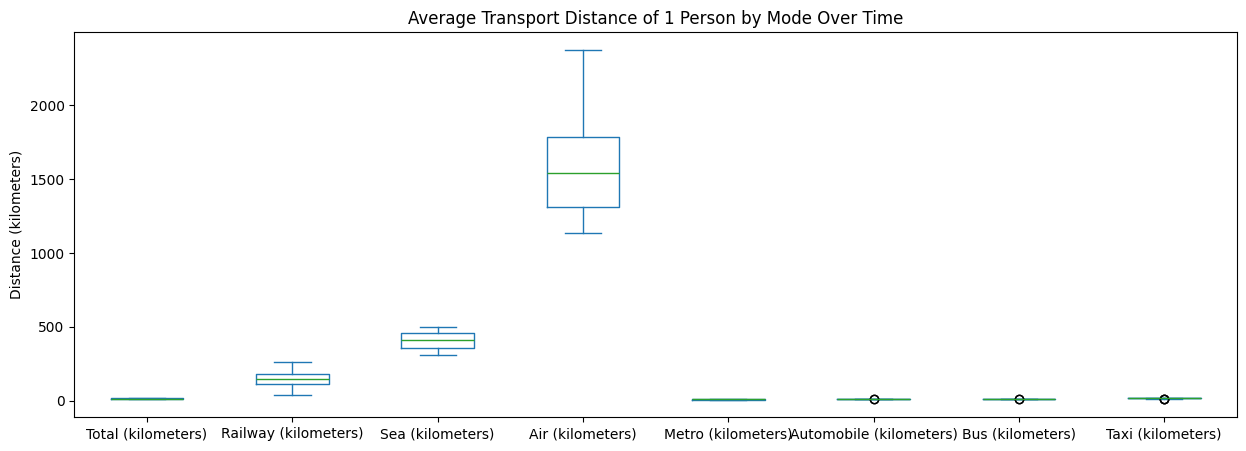

In [18]:
selected_columns_df4 = [
    'Total (kilometers)',
    'Railway (kilometers)',
    'Sea (kilometers)',
    'Air (kilometers)',
    'Metro (kilometers)',
    'Automobile (kilometers)',
    'Bus (kilometers)',
    'Taxi (kilometers)'
]

df4[selected_columns_df4].plot(
    kind='box',
    figsize=(15, 5),
    title='Average Transport Distance of 1 Person by Mode Over Time'
)

plt.ylabel('Distance (kilometers)')
plt.show()

# Merged Analyze

## Revenue vs. Passenger Count by Mode

Analyze the relationship between revenue (from `df1`) and passenger count (from `df2`) for 'Air', 'Metro', and 'Bus' transportation modes over time, visualizing their trends to identify correlations.


In [19]:
df_combined = pd.merge(df1, df2, left_index=True, right_index=True, how='inner')
df_combined.head()

,Total Revenue (per thousand manats),Railway,Sea,Air,Automobile,Bus,Taxi,Metro,Total (thousand passengers),Between Cities (thousand passengers),...,Railway – Intercity (thousand passengers),Sea – Intercity (thousand passengers),Air – Intercity (thousand passengers),Suburban (thousand passengers),Bus – Suburban (thousand passengers),Railway – Suburban (thousand passengers),Urban (thousand passengers),Bus – Urban (thousand passengers),Taxi – Urban (thousand passengers),Metro – Urban (thousand passengers)
Year,,,,,,,,,,,,,,,,,,,,,
1995-01-01,74114.0,1053.0,2809.0,48605.0,19063.0,17065.0,1998.0,2120.0,671911.0,10659.0,...,2560.0,60.0,1131.0,145577.0,139182.0,6395.0,515675.0,330075.0,9844.0,150000.0
1996-01-01,84765.0,1140.0,1150.0,57119.0,21830.0,17034.0,4796.0,3058.0,721349.0,8009.0,...,1499.0,39.0,1251.0,139729.0,136648.0,3081.0,573611.0,370601.0,10468.0,171598.0
1997-01-01,114437.0,1602.0,1074.0,45501.0,61229.0,48965.0,12264.0,4437.0,780810.0,11833.0,...,1382.0,43.0,1122.0,191618.0,189211.0,2407.0,577359.0,382596.0,19323.0,159527.0
1998-01-01,133338.0,4188.0,446.0,40639.0,82827.0,62869.0,19958.0,4666.0,850070.0,13564.0,...,1282.0,20.0,833.0,193271.0,190266.0,3005.0,643235.0,467290.0,19782.0,143823.0
1999-01-01,127668.0,3013.0,381.0,31094.0,88429.0,64567.0,23862.0,4475.0,854099.0,20441.0,...,897.0,14.0,697.0,185801.0,182649.0,3152.0,647857.0,499568.0,21458.0,119249.0


In [20]:
df_combined['Total Bus Passengers'] = df_combined['Bus – Intercity (thousand passengers)'] + \
                                       df_combined['Bus – Suburban (thousand passengers)'] + \
                                       df_combined['Bus – Urban (thousand passengers)']
df_combined.head()

,Total Revenue (per thousand manats),Railway,Sea,Air,Automobile,Bus,Taxi,Metro,Total (thousand passengers),Between Cities (thousand passengers),...,Sea – Intercity (thousand passengers),Air – Intercity (thousand passengers),Suburban (thousand passengers),Bus – Suburban (thousand passengers),Railway – Suburban (thousand passengers),Urban (thousand passengers),Bus – Urban (thousand passengers),Taxi – Urban (thousand passengers),Metro – Urban (thousand passengers),Total Bus Passengers
Year,,,,,,,,,,,,,,,,,,,,,
1995-01-01,74114.0,1053.0,2809.0,48605.0,19063.0,17065.0,1998.0,2120.0,671911.0,10659.0,...,60.0,1131.0,145577.0,139182.0,6395.0,515675.0,330075.0,9844.0,150000.0,476165.0
1996-01-01,84765.0,1140.0,1150.0,57119.0,21830.0,17034.0,4796.0,3058.0,721349.0,8009.0,...,39.0,1251.0,139729.0,136648.0,3081.0,573611.0,370601.0,10468.0,171598.0,512469.0
1997-01-01,114437.0,1602.0,1074.0,45501.0,61229.0,48965.0,12264.0,4437.0,780810.0,11833.0,...,43.0,1122.0,191618.0,189211.0,2407.0,577359.0,382596.0,19323.0,159527.0,581093.0
1998-01-01,133338.0,4188.0,446.0,40639.0,82827.0,62869.0,19958.0,4666.0,850070.0,13564.0,...,20.0,833.0,193271.0,190266.0,3005.0,643235.0,467290.0,19782.0,143823.0,668985.0
1999-01-01,127668.0,3013.0,381.0,31094.0,88429.0,64567.0,23862.0,4475.0,854099.0,20441.0,...,14.0,697.0,185801.0,182649.0,3152.0,647857.0,499568.0,21458.0,119249.0,701050.0


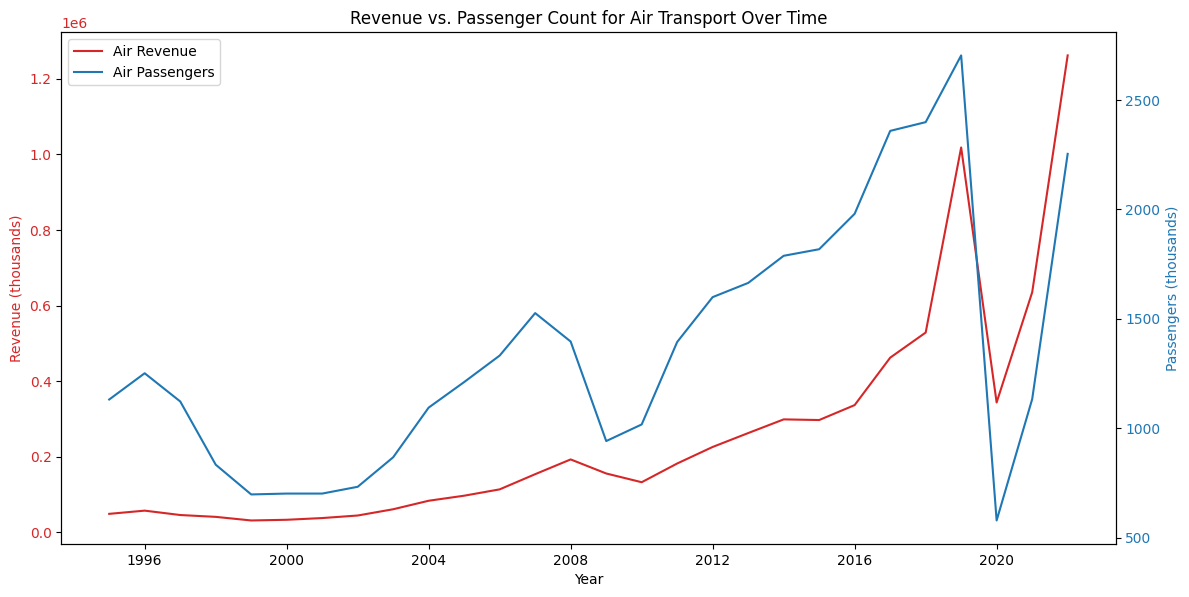

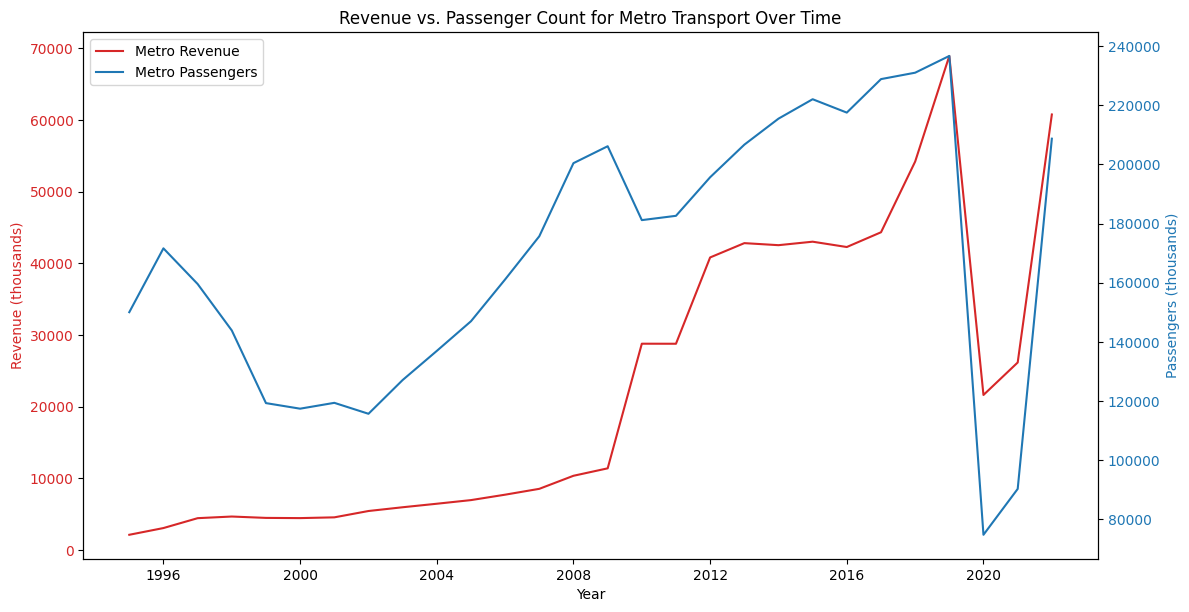

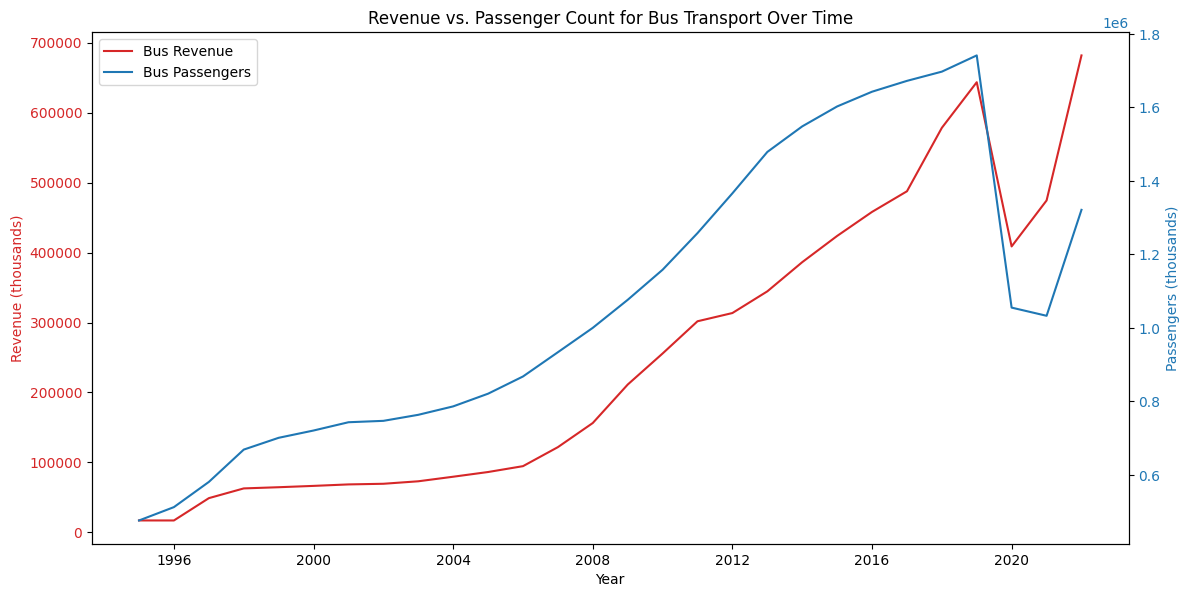

In [21]:
modes = {
    'Air': {'revenue_col': 'Air', 'passenger_col': 'Air – Intercity (thousand passengers)', 'title_suffix': 'Air Transport'},
    'Metro': {'revenue_col': 'Metro', 'passenger_col': 'Metro – Urban (thousand passengers)', 'title_suffix': 'Metro Transport'},
    'Bus': {'revenue_col': 'Bus', 'passenger_col': 'Total Bus Passengers', 'title_suffix': 'Bus Transport'}
}

for mode, cols in modes.items():
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:red'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Revenue (thousands)', color=color)
    ax1.plot(df_combined.index, df_combined[cols['revenue_col']], color=color, label=f'{mode} Revenue')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Passengers (thousands)', color=color)
    ax2.plot(df_combined.index, df_combined[cols['passenger_col']], color=color, label=f'{mode} Passengers')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.title(f"Revenue vs. Passenger Count for {cols['title_suffix']} Over Time")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.show()

## Macroeconomic Impact on Total Revenue

Merge relevant columns from `df3` (Macroeconomic Indicators) with the 'Total Revenue' from `df1`. This step will explore how macroeconomic indicators like 'Value added' or 'Investments in fixed capital' correlate with the overall revenue in the transport sector. A multi-axis line plot could be effective here to show different scales.


In [22]:
df_macro_revenue = pd.merge(df1['Total Revenue (per thousand manats)'], df3, left_index=True, right_index=True, how='inner')
df_macro_revenue.head()

,Total Revenue (per thousand manats),Value added (current prices) (thousand manats),Gross profit (current prices) (thousand manats),Net profit (current prices) (thousand manats),Average monthly nominal wage (thousand manats),Fixed assets (end of year) (thousand manats),Investments in fixed capital (thousand manats)
Year,,,,,,,
1998-01-01,133338.0,324000.0,245000.0,131000.0,0.058,1853000.0,53000.0
1999-01-01,127668.0,315000.0,201000.0,105000.0,0.048,1925000.0,84000.0
2000-01-01,134130.0,453000.0,327000.0,229000.0,0.052,2064000.0,44000.0
2001-01-01,143478.0,436000.0,309000.0,224000.0,0.060,2156000.0,59000.0
2002-01-01,154515.0,474000.0,334000.0,250000.0,0.066,2102000.0,89000.0


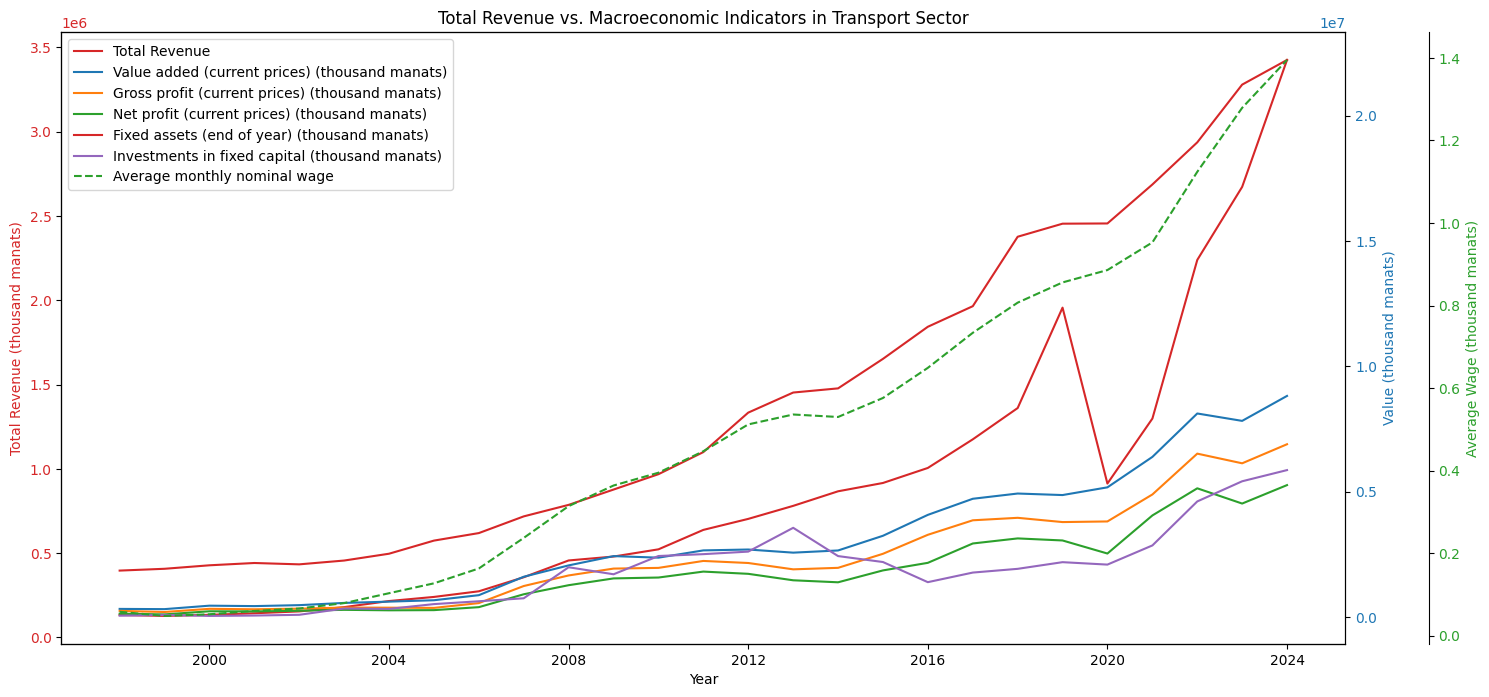

In [23]:
fig, ax1 = plt.subplots(figsize=(15, 7))

color1 = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Revenue (thousand manats)', color=color1)
ax1.plot(df_macro_revenue.index, df_macro_revenue['Total Revenue (per thousand manats)'], color=color1, label='Total Revenue')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
macro_cols_large = [
    'Value added (current prices) (thousand manats)',
    'Gross profit (current prices) (thousand manats)',
    'Net profit (current prices) (thousand manats)',
    'Fixed assets (end of year) (thousand manats)',
    'Investments in fixed capital (thousand manats)'
]
color2 = 'tab:blue'
ax2.set_ylabel('Value (thousand manats)', color=color2)
for col in macro_cols_large:
    ax2.plot(df_macro_revenue.index, df_macro_revenue[col], label=col)
ax2.tick_params(axis='y', labelcolor=color2)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'tab:green'
ax3.set_ylabel('Average Wage (thousand manats)', color=color3)
ax3.plot(df_macro_revenue.index, df_macro_revenue['Average monthly nominal wage (thousand manats)'], color=color3, linestyle='--', label='Average monthly nominal wage')
ax3.tick_params(axis='y', labelcolor=color3)

fig.tight_layout()
plt.title('Total Revenue vs. Macroeconomic Indicators in Transport Sector')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc='upper left')

plt.show()

## Average Distance vs. Passenger Count for Key Modes

Combine `df4` (Average Transport Distance) and `df2` (Passenger Count) for selected modes like 'Railway', 'Air', 'Bus', and 'Metro'. Visualize how average travel distance for these modes relates to their respective passenger numbers over time, using line plots to identify any trends or correlations.


In [24]:
df_distance_passenger = pd.merge(df4, df2, left_index=True, right_index=True, how='inner')
df_distance_passenger.head()

,Total (kilometers),Railway (kilometers),Sea (kilometers),Air (kilometers),Metro (kilometers),Automobile (kilometers),Bus (kilometers),Taxi (kilometers),Total (thousand passengers),Between Cities (thousand passengers),...,Railway – Intercity (thousand passengers),Sea – Intercity (thousand passengers),Air – Intercity (thousand passengers),Suburban (thousand passengers),Bus – Suburban (thousand passengers),Railway – Suburban (thousand passengers),Urban (thousand passengers),Bus – Urban (thousand passengers),Taxi – Urban (thousand passengers),Metro – Urban (thousand passengers)
Year,,,,,,,,,,,,,,,,,,,,,
1995-01-01,12.8,88.3,398.3,1532.2,8.8,9.6,9.5,12.1,671911.0,10659.0,...,2560.0,60.0,1131.0,145577.0,139182.0,6395.0,515675.0,330075.0,9844.0,150000.0
1996-01-01,12.1,121.8,312.8,1434.3,7.4,9.6,9.5,10.7,721349.0,8009.0,...,1499.0,39.0,1251.0,139729.0,136648.0,3081.0,573611.0,370601.0,10468.0,171598.0
1997-01-01,12.5,129.1,358.1,1285.2,7.4,11.0,11.0,11.1,780810.0,11833.0,...,1382.0,43.0,1122.0,191618.0,189211.0,2407.0,577359.0,382596.0,19323.0,159527.0
1998-01-01,13.4,124.3,415.0,1409.2,7.5,12.4,12.3,15.3,850070.0,13564.0,...,1282.0,20.0,833.0,193271.0,190266.0,3005.0,643235.0,467290.0,19782.0,143823.0
1999-01-01,13.0,104.2,428.6,1198.0,7.5,12.3,12.1,18.1,854099.0,20441.0,...,897.0,14.0,697.0,185801.0,182649.0,3152.0,647857.0,499568.0,21458.0,119249.0


In [25]:
df_distance_passenger['Total Bus Passengers'] = df_distance_passenger['Bus – Intercity (thousand passengers)'] + \
                                       df_distance_passenger['Bus – Suburban (thousand passengers)'] + \
                                       df_distance_passenger['Bus – Urban (thousand passengers)']
df_distance_passenger.head()

,Total (kilometers),Railway (kilometers),Sea (kilometers),Air (kilometers),Metro (kilometers),Automobile (kilometers),Bus (kilometers),Taxi (kilometers),Total (thousand passengers),Between Cities (thousand passengers),...,Sea – Intercity (thousand passengers),Air – Intercity (thousand passengers),Suburban (thousand passengers),Bus – Suburban (thousand passengers),Railway – Suburban (thousand passengers),Urban (thousand passengers),Bus – Urban (thousand passengers),Taxi – Urban (thousand passengers),Metro – Urban (thousand passengers),Total Bus Passengers
Year,,,,,,,,,,,,,,,,,,,,,
1995-01-01,12.8,88.3,398.3,1532.2,8.8,9.6,9.5,12.1,671911.0,10659.0,...,60.0,1131.0,145577.0,139182.0,6395.0,515675.0,330075.0,9844.0,150000.0,476165.0
1996-01-01,12.1,121.8,312.8,1434.3,7.4,9.6,9.5,10.7,721349.0,8009.0,...,39.0,1251.0,139729.0,136648.0,3081.0,573611.0,370601.0,10468.0,171598.0,512469.0
1997-01-01,12.5,129.1,358.1,1285.2,7.4,11.0,11.0,11.1,780810.0,11833.0,...,43.0,1122.0,191618.0,189211.0,2407.0,577359.0,382596.0,19323.0,159527.0,581093.0
1998-01-01,13.4,124.3,415.0,1409.2,7.5,12.4,12.3,15.3,850070.0,13564.0,...,20.0,833.0,193271.0,190266.0,3005.0,643235.0,467290.0,19782.0,143823.0,668985.0
1999-01-01,13.0,104.2,428.6,1198.0,7.5,12.3,12.1,18.1,854099.0,20441.0,...,14.0,697.0,185801.0,182649.0,3152.0,647857.0,499568.0,21458.0,119249.0,701050.0


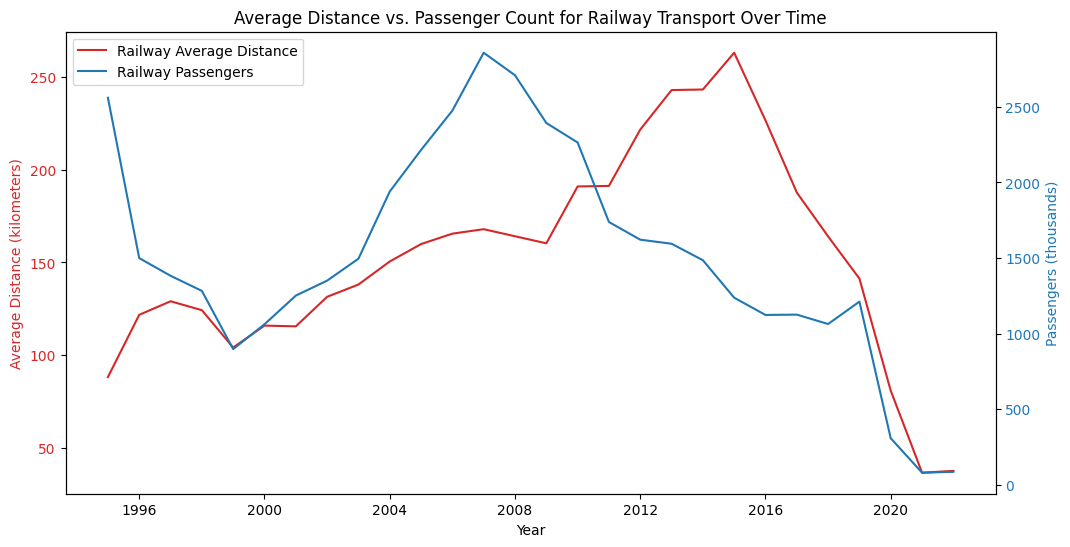

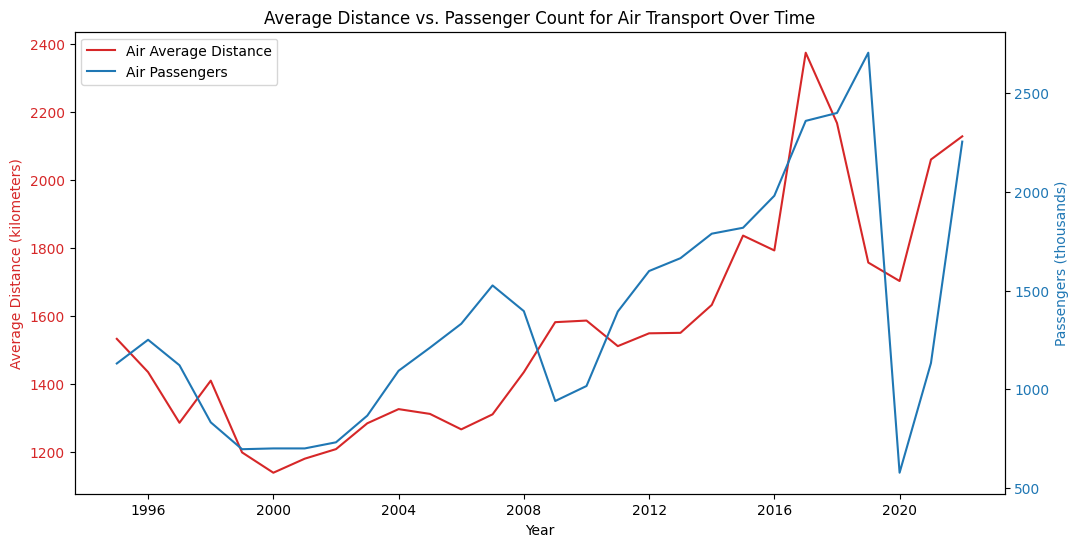

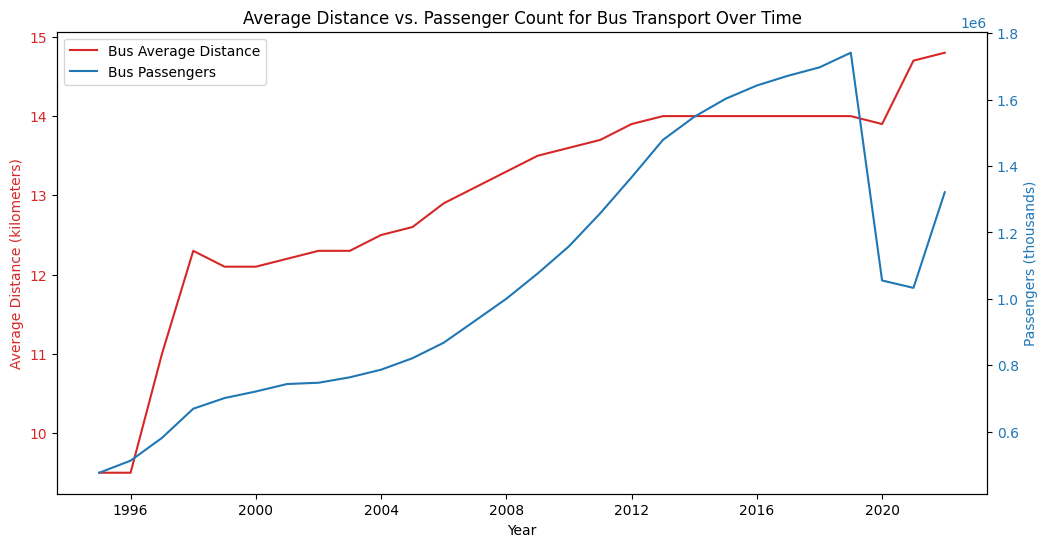

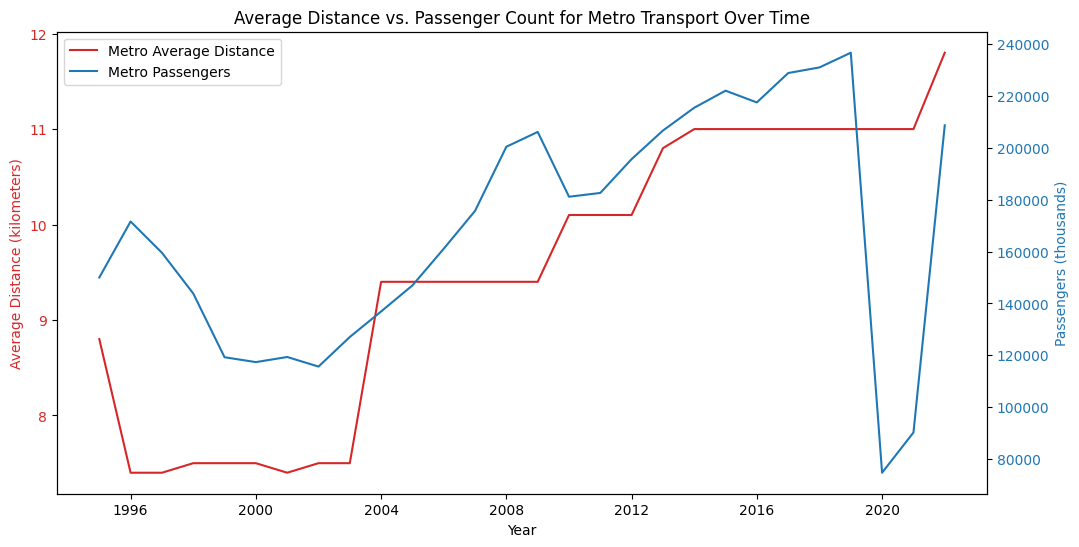

In [26]:
modes_to_plot = {
    'Railway': {'distance_col': 'Railway (kilometers)', 'passenger_col': 'Railway – Intercity (thousand passengers)', 'title_suffix': 'Railway Transport'},
    'Air': {'distance_col': 'Air (kilometers)', 'passenger_col': 'Air – Intercity (thousand passengers)', 'title_suffix': 'Air Transport'},
    'Bus': {'distance_col': 'Bus (kilometers)', 'passenger_col': 'Total Bus Passengers', 'title_suffix': 'Bus Transport'},
    'Metro': {'distance_col': 'Metro (kilometers)', 'passenger_col': 'Metro – Urban (thousand passengers)', 'title_suffix': 'Metro Transport'}
}

for mode, cols in modes_to_plot.items():
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color_distance = 'tab:red'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average Distance (kilometers)', color=color_distance)
    ax1.plot(df_distance_passenger.index, df_distance_passenger[cols['distance_col']], color=color_distance, label=f'{mode} Average Distance')
    ax1.tick_params(axis='y', labelcolor=color_distance)

    ax2 = ax1.twinx()
    color_passenger = 'tab:blue'
    ax2.set_ylabel('Passengers (thousands)', color=color_passenger)
    ax2.plot(df_distance_passenger.index, df_distance_passenger[cols['passenger_col']], color=color_passenger, label=f'{mode} Passengers')
    ax2.tick_params(axis='y', labelcolor=color_passenger)

    plt.title(f"Average Distance vs. Passenger Count for {cols['title_suffix']} Over Time")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.show()


In [27]:
df_profit_revenue = pd.merge(df1, df3, left_index=True, right_index=True, how='inner')
df_profit_revenue = df_profit_revenue[['Net profit (current prices) (thousand manats)', 'Gross profit (current prices) (thousand manats)', 'Air', 'Metro', 'Bus']]
df_profit_revenue.head()

,Net profit (current prices) (thousand manats),Gross profit (current prices) (thousand manats),Air,Metro,Bus
Year,,,,,
1998-01-01,131000.0,245000.0,40639.0,4666.0,62869.0
1999-01-01,105000.0,201000.0,31094.0,4475.0,64567.0
2000-01-01,229000.0,327000.0,32925.0,4446.0,66473.0
2001-01-01,224000.0,309000.0,37494.0,4552.0,68583.0
2002-01-01,250000.0,334000.0,44222.0,5436.0,69501.0


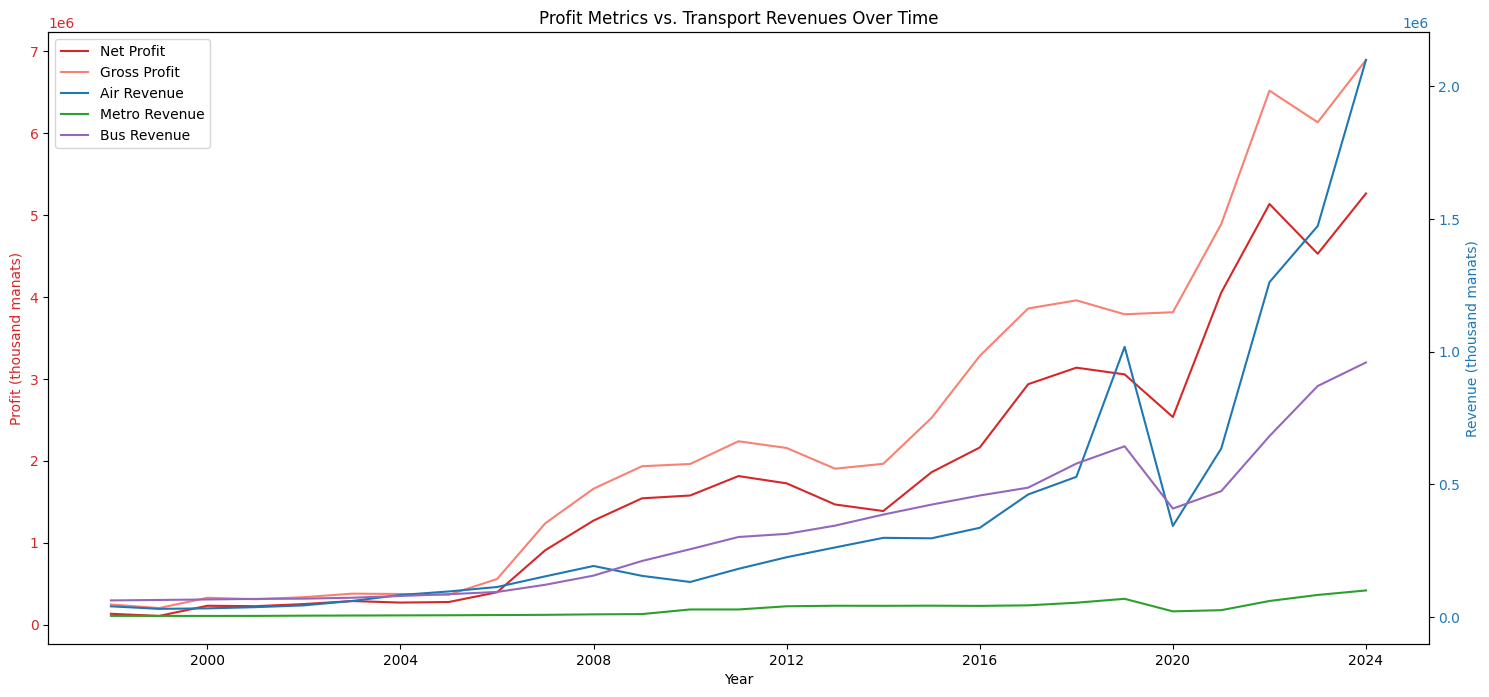

In [28]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# Profit metrics on the first y-axis
profit_cols_data = [
    {'column': 'Net profit (current prices) (thousand manats)', 'label': 'Net Profit', 'color': 'tab:red'},
    {'column': 'Gross profit (current prices) (thousand manats)', 'label': 'Gross Profit', 'color': 'salmon'}
]
ax1.set_xlabel('Year')
ax1.set_ylabel('Profit (thousand manats)', color='tab:red')
for item in profit_cols_data:
    ax1.plot(df_profit_revenue.index, df_profit_revenue[item['column']], color=item['color'], label=item['label'])
ax1.tick_params(axis='y', labelcolor='tab:red')

# Transport revenues on the second y-axis
ax2 = ax1.twinx()
revenue_cols_data = [
    {'column': 'Air', 'label': 'Air Revenue', 'color': 'tab:blue'},
    {'column': 'Metro', 'label': 'Metro Revenue', 'color': 'tab:green'},
    {'column': 'Bus', 'label': 'Bus Revenue', 'color': 'tab:purple'}
]
ax2.set_ylabel('Revenue (thousand manats)', color='tab:blue')
for item in revenue_cols_data:
    ax2.plot(df_profit_revenue.index, df_profit_revenue[item['column']], color=item['color'], label=item['label'])
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()
plt.title('Profit Metrics vs. Transport Revenues Over Time')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.show()

## Bonus

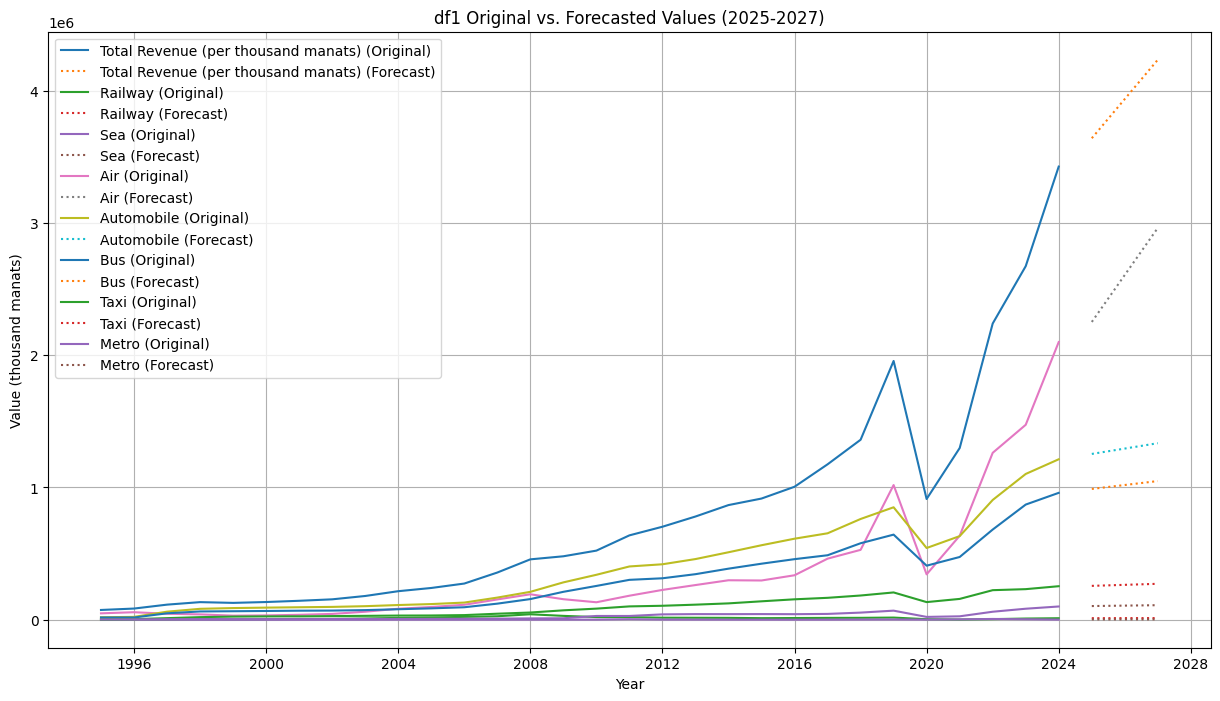

'Forecasted values for df1:'

,Total Revenue (per thousand manats),Railway,Sea,Air,Automobile,Bus,Taxi,Metro
2025-01-01,3.639527e+06,12063.005534,2841.986788,2.251075e+06,1.253533e+06,9.889918e+05,256273.687421,103713.285758
2026-01-01,3.936219e+06,12430.011100,2881.729162,2.606486e+06,1.294065e+06,1.018665e+06,264058.126667,106988.571719
2027-01-01,4.232911e+06,12797.016665,2921.471536,2.961897e+06,1.334596e+06,1.048337e+06,271842.565914,110263.857680


In [29]:
future_dates = pd.to_datetime(['2025-01-01', '2026-01-01', '2027-01-01'])

df1.index.freq = 'YS'

forecasts_df1 = pd.DataFrame(index=future_dates)

for column in df1.columns:
    if pd.api.types.is_numeric_dtype(df1[column]):
        try:
            model = ExponentialSmoothing(df1[column], trend='add', seasonal=None, initialization_method='estimated').fit()
            # Generate predictions for future dates
            forecast = model.predict(start=future_dates.min(), end=future_dates.max())
            forecasts_df1[column] = forecast
        except Exception as e:
            print(f"Could not forecast for column {column}: {e}")

plt.figure(figsize=(15, 8))
for column in df1.columns:
    if pd.api.types.is_numeric_dtype(df1[column]):
        plt.plot(df1.index, df1[column], label=f'{column} (Original)', linestyle='-')
        plt.plot(forecasts_df1.index, forecasts_df1[column], label=f'{column} (Forecast)', linestyle=':')

plt.title('df1 Original vs. Forecasted Values (2025-2027)')
plt.xlabel('Year')
plt.ylabel('Value (thousand manats)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

display("Forecasted values for df1:")
display(forecasts_df1)

# Convert to HTML

In [30]:
!jupyter nbconvert --to html "./analyze.ipynb" --output "my_report.html"

[NbConvertApp] Converting notebook ./analyze.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 2178920 bytes to my_report.html
